# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Lowercase
* Remove usernames, URL, hashtag and HTML tags
* Remove special caracters and nuumbers
* Remove rare words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set1.csv')
df.head()

,id,comment_text,tox
0,20ca7bad20d4c3d1,"You're an asshole, useless piece of shit. Get ...",1
1,72428510d4205ccf,Nonito Donaire \n\nIt is clearly stated in the...,0
2,f3890d4a31f0d45a,"Okay, in the future I shall no longer use the ...",0
3,29ac5b2897f7ef59,fuck off \n\ndon't fuck with me . fuck off,1
4,6f2278059a63256a,"""*E-dog, on another page, you wrote: \n\nThank...",1


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set1.csv')
test.head()

,id,comment_text,tox
0,b28eeb594e5ac00f,"AAAAWWWW, widdle wikinazis banned me.\n\nMaybe...",1
1,2f3c460abcd5479f,very crocker sucks n e g r o c o c k s i n h e...,1
2,dc3ae57fa0c30d8d,He lied on my RFC too. He's a liar.,1
3,5eb7bb36f870d2b9,"""I've removed the following:\n""""Morro Bay is a...",0
4,e9c9d9abd37bca1d,Briefcase\n\nToo much importance is given to t...,0


# 3. Preprocessing

In [4]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    comment = re.sub("@\S+", " ", comment) # Remove usernames
    comment = re.sub("https*\S+", " ", comment) # Remove URL
    comment = comment.replace("#", "") #remove hashtag
    comment = re.sub("\\<([^/> ]+)", " ", comment) # Remove HTML tags
    comment = re.sub(r'[^a-zA-Z]', ' ',comment) # remove special caracters and nuumbers 
    comment = re.sub(r'[“”¨«»®´·º½¾¿¡§£₤‘’]', ' ', comment) # Remove special characters
    
    return comment

In [5]:
# clean and normalize comments
df['comment_text'] = df['comment_text'].map(lambda word:clean_text(word))
test['comment_text'] = test['comment_text'].map(lambda word:clean_text(word))

In [6]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['comment_text']).split()).value_counts(ascending=True)[1:10]
print(dellist1)

pune           1
extradited     1
chunky         1
connaught      1
stratocracy    1
venuz          1
malodorous     1
cryptology     1
reflexively    1
dtype: int64


In [7]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['comment_text'] = df['comment_text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,id,comment_text,tox
0,20ca7bad20d4c3d1,you re an asshole useless piece of shit get a ...,1
1,72428510d4205ccf,nonito donaire it is clearly stated in the giv...,0
2,f3890d4a31f0d45a,okay in the future i shall no longer use the m...,0
3,29ac5b2897f7ef59,fuck off don t fuck with me fuck off,1
4,6f2278059a63256a,e dog on another page you wrote thanks for you...,1


In [8]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['comment_text']).split()).value_counts(ascending=True)[1:10]
print(dellist2)

trembling            1
serapio              1
republished          1
ridicilous           1
juste                1
faggotttttttttttt    1
bingo                1
roesgen              1
surrender            1
dtype: int64


In [9]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['comment_text'] = test['comment_text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,id,comment_text,tox
0,b28eeb594e5ac00f,aaaawwww widdle wikinazis banned me maybe i sh...,1
1,2f3c460abcd5479f,very crocker sucks n e g r o c o c k s i n h e...,1
2,dc3ae57fa0c30d8d,he lied on my rfc too he s a liar,1
3,5eb7bb36f870d2b9,i ve removed the following morro bay is also h...,0
4,e9c9d9abd37bca1d,briefcase too much importance is given to the ...,0


In [10]:
x_train, x_val, y_train, y_val = train_test_split(df['comment_text'], df['tox'], test_size=0.15, random_state=42)

In [11]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(22066,)
(22066,)


In [12]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(3894,)
(3894,)


In [13]:
x_test = test['comment_text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(6490,)
(6490,)


### Vectorize texts

In [14]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [15]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [16]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [17]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

60874


###  converts a class vector (integers) to binary class matrix.

In [18]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(22066, 2)

In [19]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(3894, 2)

In [20]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(6490, 2)

In [21]:
Y_val[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

In [22]:
Y_test[:2]

array([[0., 1.],
       [0., 1.]], dtype=float32)

In [23]:
Y_train[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

# 3. Create model

In [24]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [25]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          24349600  
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 24,587,938
Trainable params: 24,587,938
Non-trainable params: 0
_________________________________________________________________


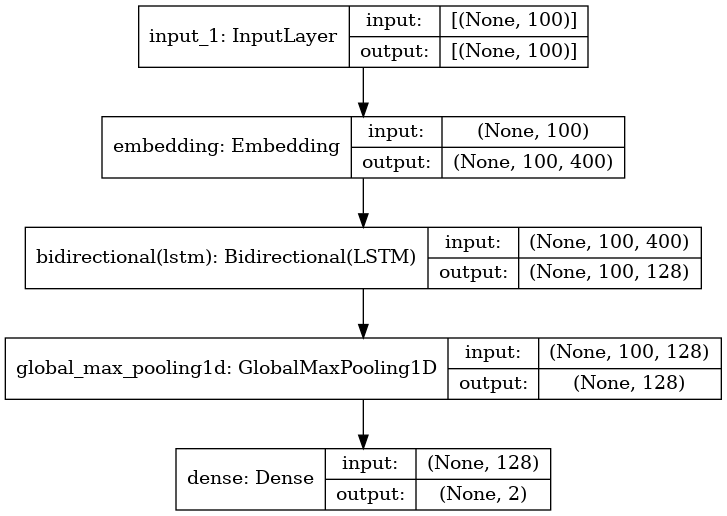

In [26]:
# plot model
plot_model(model_used, show_shapes=True)

In [27]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'models/bilstm_approach#15.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [28]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [29]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
173/173 [==============================] - 206s 1s/step - loss: 0.3609 - accuracy: 0.8411 - val_loss: 0.2657 - val_accuracy: 0.8865

Epoch 00001: val_loss improved from inf to 0.26570, saving model to models/bilstm_approach#15.h5
Epoch 2/100
173/173 [==============================] - 210s 1s/step - loss: 0.1835 - accuracy: 0.9295 - val_loss: 0.2114 - val_accuracy: 0.9147

Epoch 00002: val_loss improved from 0.26570 to 0.21141, saving model to models/bilstm_approach#15.h5
Epoch 3/100
173/173 [==============================] - 215s 1s/step - loss: 0.1453 - accuracy: 0.9450 - val_loss: 0.2060 - val_accuracy: 0.9178

Epoch 00003: val_loss improved from 0.21141 to 0.20598, saving model to models/bilstm_approach#15.h5
Epoch 4/100
173/173 [==============================] - 203s 1s/step - loss: 0.1196 - accuracy: 0.9549 - val_loss: 0.2332 - val_accuracy: 0.9058

Epoch 00004: val_loss did not improve from 0.20598
Epoch 5/100
173/173 [==============================] - 190s 1s/step - 

### Evaluate metrics

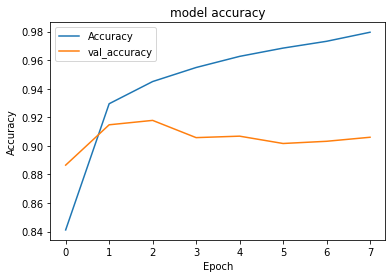

In [30]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

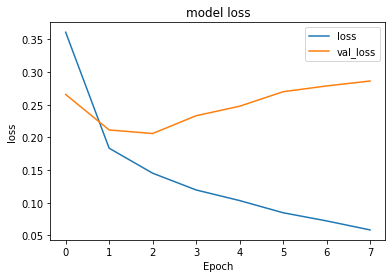

In [31]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [32]:
from keras.models import load_model
saved_model = load_model("models/bilstm_approach#15.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


173/173 [==============================] - 30s 169ms/step - loss: 0.1086 - accuracy: 0.9616


In [33]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.109
train acc: 0.962


In [34]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

31/31 [==============================] - 5s 176ms/step - loss: 0.2060 - accuracy: 0.9178


In [35]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.206
validation acc: 0.918


In [36]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [37]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

51/51 [==============================] - 10s 196ms/step


In [38]:
print(y_pred)

[[2.7429287e-05 9.9997258e-01]
 [1.5419479e-04 9.9984574e-01]
 [1.1294214e-03 9.9887055e-01]
 ...
 [9.9998784e-01 1.2129100e-05]
 [9.9940550e-01 5.9447653e-04]
 [9.9729222e-01 2.7078036e-03]]


In [39]:
print(Y_train)

[[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [0. 1.]
 [1. 0.]]


In [40]:
print(Y_test)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [41]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.91

 Confusion matrix

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      3221
           1       0.93      0.90      0.91      3269

    accuracy                           0.91      6490
   macro avg       0.91      0.91      0.91      6490
weighted avg       0.91      0.91      0.91      6490



In [42]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[2990  231]
 [ 326 2943]]


In [43]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.9142
recall :  0.9003
F1_score :  0.9135
precision :  0.9272


# 5. Save results to Excel file

In [44]:
# define tarjet
newFile = "../results_BiLSTM_set1.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #15', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 17

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)